In [19]:
import os
import pickle
import numpy as np

dir = "../../bash_scripts/data_g2/20260303_025813"

d = {}

for folder in os.listdir(dir):

    # get the parameters from dir name
    hg, gamma, phi = folder.split('_')
    hg, gamma, phi = float(hg), float(gamma), float(phi)

    # load the results pkl as dict
    with open(os.path.join(dir, folder, 'results.pkl'), 'rb') as fp:
        d_result = pickle.load(fp)

    # check if entries already loaded, otherwise initialize
    if hg not in d:
        d[hg] = {}
    if gamma not in d[hg]:
        d[hg][gamma] ={}

    # store loaded results
    d[hg][gamma][phi] = d_result

hgs = np.array(list(d.keys()))
gammas = np.array(list(d[hgs[0]].keys()))
phis = np.array(list(d[hgs[0]][gammas[0]].keys()))

hgs.sort(), gammas.sort(), phis.sort()

ks = d[10][0.00][0.0]['ks']
data_shape = d[10][0.00][0.0]['g2s'].shape
keys = d[10][0.00][0.0].keys()
params = d[10][0.00][0.0]['parameters']

print(rf"hg: {hgs} $\mu eV\, \mu m^2$")
print(f"gamma: {gammas} 1/ps")
print(f"phi: {phis}")
print(f"keys: {keys}")
print(params)
    

hg: [  0.  10.  20.  30.  40.  50.  60.  70.  80.  90. 100. 120. 140. 170.
 200. 300. 400. 500. 600. 700.] $\mu eV\, \mu m^2$
gamma: [0.   0.02 0.04 0.06 0.08 0.1 ] 1/ps
phi: [0.  0.2 0.4 0.6 0.8 1. ]
keys: dict_keys(['ks', 'g2s', 'ns', 'Uk', 'coupling_k', 'ex_frac', 'wk', 'vgk', 'parameters'])
{'num_channels': 6, 'num_layers': 5, 'Nmax': 20, 'hg_ex': 10.0, 'gamma': 0.0, 'alphas': [np.float64(1.0), 0.0, 0.0, 0.0, 0.0, np.complex128(1+0j)]}


In [20]:
np.argmin(np.abs((d[10][0.00][0.0]['ex_frac'] - 0.3)))

np.int64(38)

# Plot a single g2 outcome, function of k

/tmp/ipykernel_157753/361390719.py:45: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[0].set_ylim(bottom=0.)
/tmp/ipykernel_157753/361390719.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()      # respects the added hspace


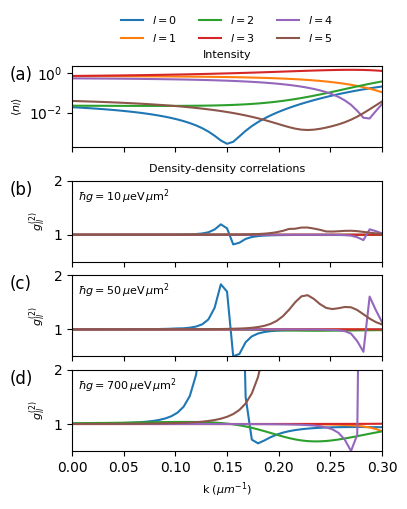

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ------------------------------------------------------------------
# 1️⃣  Load / compute the data (your original snippet)
# ------------------------------------------------------------------
gamma = 0.
phi   = 0.6


ks = d[10.][gamma][phi]['ks']
hgs_plot = [10., 50., 700.]
ns = np.array([d[hg][gamma][phi]['ns'] for hg in hgs_plot])

g2s_10  = d[10.][gamma][phi]['g2s']
g2s_50  = d[50.][gamma][phi]['g2s']
g2s_700 = d[700.][gamma][phi]['g2s']

# ------------------------------------------------------------------
# 2️⃣  Create the figure and the four axes
# ------------------------------------------------------------------
#fig, ax = plt.subplots(4, 1, figsize=(4, 5), sharex=True)
fig = plt.figure(figsize=(4, 5))
gs  = GridSpec(
        nrows=5, ncols=1,
        height_ratios=[1, 0.08, 1, 1, 1],   # <‑‑ the 0.08 row is the “big gap”
        hspace=0.2                         # normal gap between the *real* rows
    )

# real axes (skip row 1, which will stay empty)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[2, 0])
ax2 = fig.add_subplot(gs[3, 0])
ax3 = fig.add_subplot(gs[4, 0])
ax  = [ax0, ax1, ax2, ax3] 

# ------------------------------------------------------------------
# 3️⃣  Plot each panel (identical to your original code)
# ------------------------------------------------------------------
# panel (a) – density ⟨nₗ⟩

ax[0].semilogy(ks, ns[0])
ax[0].tick_params(axis='x', labelbottom=False)
ax[0].set_ylim(bottom=0.)
ax[0].set_ylabel(r"$\langle n_l \rangle$", fontsize=8)
ax[0].set_title("Intensity", fontsize=8)

# panel (b) – g² for ℏg = 10 µeV µm²
ax[1].plot(ks, g2s_10)
ax[1].tick_params(axis='x', labelbottom=False)
ax[1].set_ylabel(r"$g^{(2)}_{ll}$", fontsize=8)
ax[1].set_title("Density-density correlations", fontsize=8)

# panel (c) – g² for ℏg = 50 µeV µm²
ax[2].plot(ks, g2s_50)
ax[2].tick_params(axis='x', labelbottom=False)
ax[2].set_ylabel(r"$g^{(2)}_{ll}$", fontsize=8)

# panel (d) – g² for ℏg = 700 µeV µm²
ax[3].plot(ks, g2s_700)
ax[3].set_xlabel(r"k $(\mu m ^{-1})$", fontsize=8)
ax[3].set_ylabel(r"$g^{(2)}_{ll}$", fontsize=8)

# ------------------------------------------------------------------
# 4️⃣  Common axis limits
# ------------------------------------------------------------------
for a in ax:
    a.set_xlim([np.min(ks), np.max(ks)])

for a in ax[1:]:
    a.set_ylim([0.5, 2.])

# ------------------------------------------------------------------
# 5️⃣  **Add vertical whitespace** between the sub‑panels
# ------------------------------------------------------------------
# `hspace` is the fraction of the average axis height that will be used
# as padding. 0.4 gives a noticeable gap without blowing the figure up.
fig.subplots_adjust(hspace=0.)


panel_labels = ['(a)', '(b)', '(c)', '(d)']
for i, a in enumerate(ax):
    # `transform=a.transAxes` means the coordinates are relative to the
    # axis (0,0) = lower‑left, (1,1) = upper‑right.
    a.text(
        -0.2,                     # x‑position (a few % from the left)
        1.,                     # y‑position (just below the top edge)
        panel_labels[i],
        transform=a.transAxes,
        fontsize=12,
        #fontweight='bold',
        va='top',
        ha='left'
    )


extra_text = [
    '',#r'Intensities: $\langle n_l \rangle$',
    r'$\hbar g = 10\,\mu\text{eV}\,\mu\text{m}^2$',
    r'$\hbar g = 50\,\mu\text{eV}\,\mu\text{m}^2$',
    r'$\hbar g = 700\,\mu\text{eV}\,\mu\text{m}^2$'
]

for i, a in enumerate(ax):
    a.text(
        0.02,                     # start a little to the right of the label
        0.92,
        extra_text[i],
        transform=a.transAxes,
        fontsize=8,
        va='top',
        ha='left'
    )


legend_labels = [fr'$l={i}$' for i in range(7)]

# `bbox_to_anchor` places the legend relative to the Axes bounding box.
# (0.5, 1.05) means centered horizontally, just above the top edge.
ax[0].legend(
    legend_labels,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=3,                # put all entries on one row
    frameon=False,
    fontsize=8
)


fig.tight_layout()      # respects the added hspace
plt.show()

phi=0.0pi


/tmp/ipykernel_157753/3322890919.py:47: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[0].set_ylim(bottom=0.)
/tmp/ipykernel_157753/3322890919.py:133: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()      # respects the added hspace


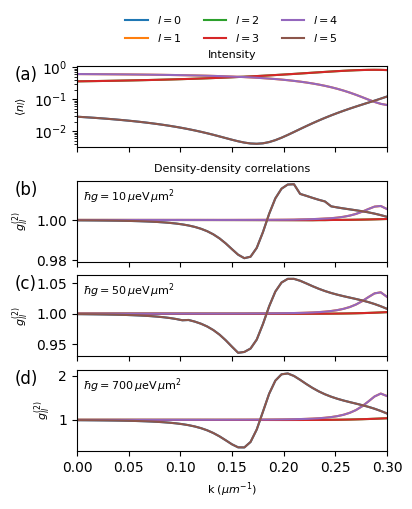

phi=0.2pi


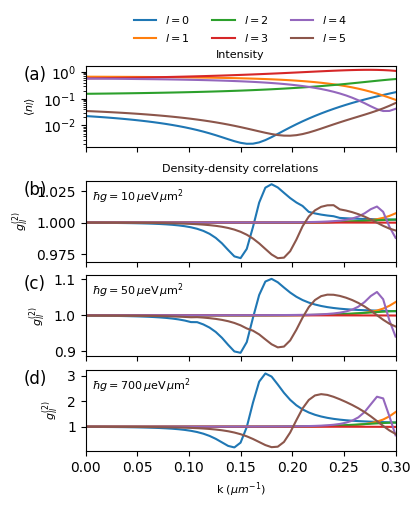

phi=0.4pi


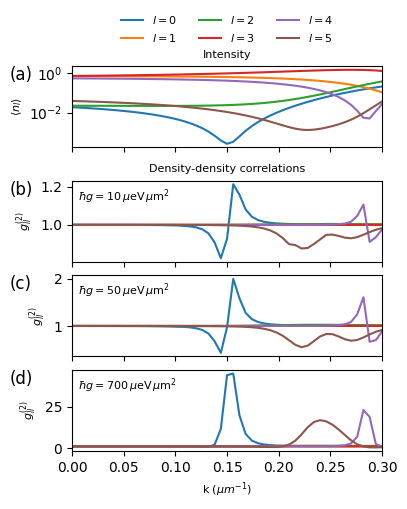

phi=0.6pi


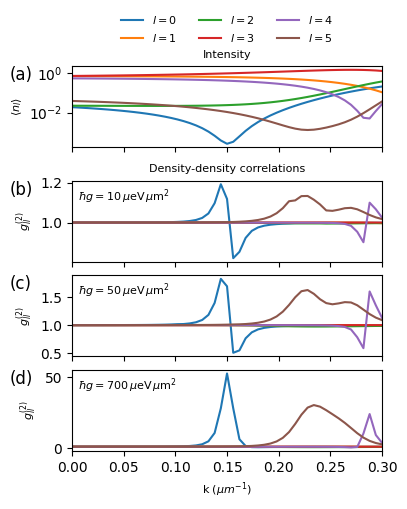

phi=0.8pi


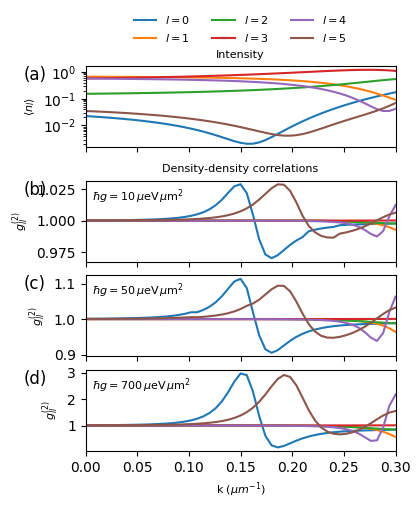

phi=1.0pi


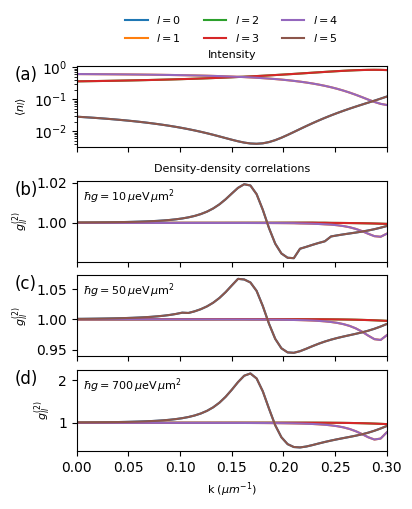

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ------------------------------------------------------------------
# 1️⃣  Load / compute the data (your original snippet)
# ------------------------------------------------------------------
gamma = 0.

for phi in phis:

    print(f"phi={phi}pi")

    ks = d[10.][gamma][phi]['ks']
    hgs_plot = [10., 50., 700.]
    ns = np.array([d[hg][gamma][phi]['ns'] for hg in hgs_plot])

    g2s_10  = d[10.][gamma][phi]['g2s']
    g2s_50  = d[50.][gamma][phi]['g2s']
    g2s_700 = d[700.][gamma][phi]['g2s']

    # ------------------------------------------------------------------
    # 2️⃣  Create the figure and the four axes
    # ------------------------------------------------------------------
    #fig, ax = plt.subplots(4, 1, figsize=(4, 5), sharex=True)
    fig = plt.figure(figsize=(4, 5))
    gs  = GridSpec(
            nrows=5, ncols=1,
            height_ratios=[1, 0.08, 1, 1, 1],   # <‑‑ the 0.08 row is the “big gap”
            hspace=0.2                         # normal gap between the *real* rows
        )

    # real axes (skip row 1, which will stay empty)
    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[2, 0])
    ax2 = fig.add_subplot(gs[3, 0])
    ax3 = fig.add_subplot(gs[4, 0])
    ax  = [ax0, ax1, ax2, ax3] 

    # ------------------------------------------------------------------
    # 3️⃣  Plot each panel (identical to your original code)
    # ------------------------------------------------------------------
    # panel (a) – density ⟨nₗ⟩

    ax[0].semilogy(ks, ns[0])
    ax[0].tick_params(axis='x', labelbottom=False)
    ax[0].set_ylim(bottom=0.)
    ax[0].set_ylabel(r"$\langle n_l \rangle$", fontsize=8)
    ax[0].set_title("Intensity", fontsize=8)

    # panel (b) – g² for ℏg = 10 µeV µm²
    ax[1].plot(ks, g2s_10)
    ax[1].tick_params(axis='x', labelbottom=False)
    ax[1].set_ylabel(r"$g^{(2)}_{ll}$", fontsize=8)
    ax[1].set_title("Density-density correlations", fontsize=8)

    # panel (c) – g² for ℏg = 50 µeV µm²
    ax[2].plot(ks, g2s_50)
    ax[2].tick_params(axis='x', labelbottom=False)
    ax[2].set_ylabel(r"$g^{(2)}_{ll}$", fontsize=8)

    # panel (d) – g² for ℏg = 700 µeV µm²
    ax[3].plot(ks, g2s_700)
    ax[3].set_xlabel(r"k $(\mu m ^{-1})$", fontsize=8)
    ax[3].set_ylabel(r"$g^{(2)}_{ll}$", fontsize=8)

    # ------------------------------------------------------------------
    # 4️⃣  Common axis limits
    # ------------------------------------------------------------------
    for a in ax:
        a.set_xlim([np.min(ks), np.max(ks)])

    # for a in ax[1:]:
    #     a.set_ylim([0.5, 2.])

    # ------------------------------------------------------------------
    # 5️⃣  **Add vertical whitespace** between the sub‑panels
    # ------------------------------------------------------------------
    # `hspace` is the fraction of the average axis height that will be used
    # as padding. 0.4 gives a noticeable gap without blowing the figure up.
    fig.subplots_adjust(hspace=0.)


    panel_labels = ['(a)', '(b)', '(c)', '(d)']
    for i, a in enumerate(ax):
        # `transform=a.transAxes` means the coordinates are relative to the
        # axis (0,0) = lower‑left, (1,1) = upper‑right.
        a.text(
            -0.2,                     # x‑position (a few % from the left)
            1.,                     # y‑position (just below the top edge)
            panel_labels[i],
            transform=a.transAxes,
            fontsize=12,
            #fontweight='bold',
            va='top',
            ha='left'
        )


    extra_text = [
        '',#r'Intensities: $\langle n_l \rangle$',
        r'$\hbar g = 10\,\mu\text{eV}\,\mu\text{m}^2$',
        r'$\hbar g = 50\,\mu\text{eV}\,\mu\text{m}^2$',
        r'$\hbar g = 700\,\mu\text{eV}\,\mu\text{m}^2$'
    ]

    for i, a in enumerate(ax):
        a.text(
            0.02,                     # start a little to the right of the label
            0.92,
            extra_text[i],
            transform=a.transAxes,
            fontsize=8,
            va='top',
            ha='left'
        )


    legend_labels = [fr'$l={i}$' for i in range(7)]

    # `bbox_to_anchor` places the legend relative to the Axes bounding box.
    # (0.5, 1.05) means centered horizontally, just above the top edge.
    ax[0].legend(
        legend_labels,
        loc='lower center',
        bbox_to_anchor=(0.5, 1.15),
        ncol=3,                # put all entries on one row
        frameon=False,
        fontsize=8
    )


    fig.tight_layout()      # respects the added hspace
    plt.show()

In [5]:
import numpy as np

ks = d[10][0.00][0.0]['ks']
wg_select = 0
k_select = 38

g2_min = np.zeros((len(hgs), len(gammas)))
n_g2_min = np.zeros((len(hgs), len(gammas)))

for ih, hg in enumerate(hgs):
    for ig, gamma in enumerate(gammas):
        g2_min_phi = [np.nanmin(d[hg][gamma][phi]['g2s'][k_select, wg_select]) for phi in phis]
        g2_min[ih,ig] = np.min(g2_min_phi)

        # g2_min_arg_phi = [np.unravel_index(np.argmin(d[hg][gamma][phi]['g2s'][k_select]), data_shape) for phi in phis]
        # g2_min_arg_phi = [np.argmin(d[hg][gamma][phi]['g2s'][k_select]) for phi in phis]
        g2_min_arg = np.argmin(g2_min_phi)

        n_g2_min[ih,ig] = d[hg][gamma][phis[g2_min_arg]]['ns'][k_select, wg_select]
        

    

In [14]:
print(f"unitary, no losses \t {g2_min[-1,0]:.4f}")
print(f"losses {gammas[-1]} ps^(-1) \t\t{g2_min[-1,-1]:.4f}")

unitary, no losses 	 0.4794
losses 0.1 ps^(-1) 		0.4825


In [19]:
2 * (1 - 0.7) ** 1.6

0.29135602489812235

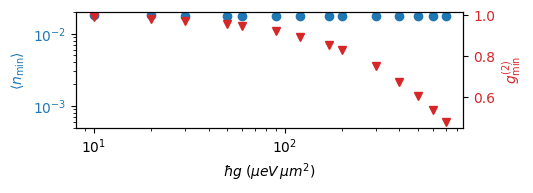

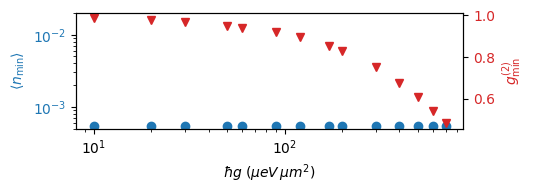

In [ ]:
inds = [1, 2, 3, 5, 6, 9, 11, 13, 14, 15, 16, 17, 18, 19]
i_gammas_plot = [0, -1]
nylim = [0.0005,0.02] #[0.9 * np.min(n_g2_min[:,i_gammas_plot]), 1.1 * np.max(n_g2_min[:,i_gammas_plot])]

for i in i_gammas_plot:
    fig, ax1 = plt.subplots(figsize=(5,1.5))
    # left y-axis (blue)
    ax1.loglog(hgs[inds], n_g2_min[inds,i], "o", color="tab:blue")
    ax1.set_xlabel(r"$\hbar g\; (\mu eV \,\mu m^2)$")
    ax1.set_ylabel(r"$\langle n_\mathrm{min} \rangle$", color="tab:blue")
    ax1.set_ylim(nylim)
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    # right y-axis (orange)
    ax2 = ax1.twinx()
    ax2.semilogx(hgs[inds], g2_min[inds, i], "v", color="tab:red")
    ax2.set_ylabel(r"$g^{(2)}_\text{min}$", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    plt.show()

In [7]:
i_hg = 
nylim = [0.0005,0.02] #[0.9 * np.min(n_g2_min[:,i_gammas_plot]), 1.1 * np.max(n_g2_min[:,i_gammas_plot])]

for i in i_gammas_plot:
    fig, ax1 = plt.subplots(figsize=(5,1.5))
    # left y-axis (blue)
    ax1.loglog(hgs[inds], n_g2_min[inds,i], "o", color="tab:blue")
    ax1.set_xlabel(r"$\hbar g\; (\mu eV \,\mu m^2)$")
    ax1.set_ylabel(r"$\langle n_\mathrm{min} \rangle$", color="tab:blue")
    ax1.set_ylim(nylim)
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    # right y-axis (orange)
    ax2 = ax1.twinx()
    ax2.semilogx(hgs[inds], g2_min[inds, i], "v", color="tab:red")
    ax2.set_ylabel(r"$g^{(2)}_\text{min}$", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    plt.show()

SyntaxError: invalid syntax (1462192255.py, line 1)

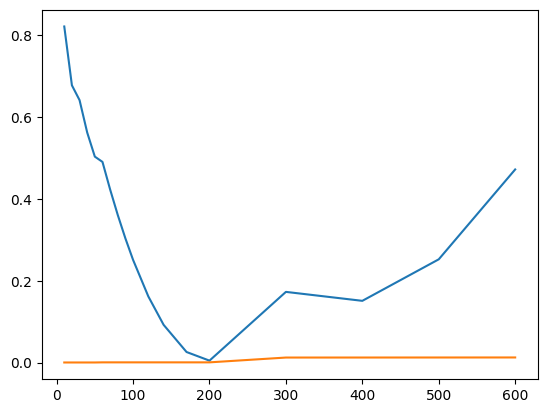

In [ ]:
import numpy as np

phi = 0.6

g2_min = np.zeros((len(hgs), len(gammas)))
n_g2_min = np.zeros((len(hgs), len(gammas)))

for ih, hg in enumerate(hgs):
    for ig, gamma in enumerate(gammas):
        g2_min[ih, ig] = np.nanmin(d[hg][gamma][phi]['g2s'])

        g2_min_arg = np.unravel_index(np.argmin(d[hg][gamma][phi]['g2s']), data_shape)

        n_g2_min[ih,ig] = d[hg][gamma][phi]['ns'][g2_min_arg]

plt.plot(hgs[1:-1], g2_min[1:-1, 0])
plt.plot(hgs[1:-1], n_g2_min[1:-1, 0])

# Minimal g2 value obtained, for (hg, gamma) values (minimized over k and phi)

In [ ]:
import numpy as np

ks = d[10][0.00][0.0]['ks']
k_select = 38

g2_min = np.zeros((len(hgs), len(gammas)))
n_g2_min = np.zeros((len(hgs), len(gammas)))

for ih, hg in enumerate(hgs):
    for ig, gamma in enumerate(gammas):
        g2_min_phi = [np.nanmin(d[hg][gamma][phi]['g2s'][k_select]) for phi in phis]
        g2_min[ih,ig] = np.min(g2_min_phi)

        # g2_min_arg_phi = [np.unravel_index(np.argmin(d[hg][gamma][phi]['g2s'][k_select]), data_shape) for phi in phis]
        # g2_min_arg_phi = [np.argmin(d[hg][gamma][phi]['g2s'][k_select]) for phi in phis]
        g2_min_arg = np.argmin(g2_min_phi)

        n_g2_min[ih,ig] = d[hg][gamma][phi]['ns'][k_select, g2_min_arg]
        

    

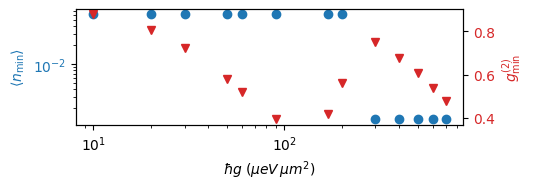

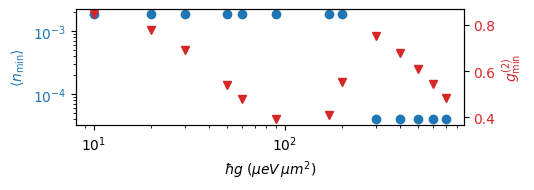

In [ ]:
inds = [1,2, 3,5, 6, 9, 13, 14, 15, 16, 17, 18, 19]
i_gammas_plot = [0, -1]
nylim = None #[0.9 * np.min(n_g2_min[:,i_gammas_plot]), 1.1 * np.max(n_g2_min[:,i_gammas_plot])]
for i in i_gammas_plot:
    fig, ax1 = plt.subplots(figsize=(5,1.5))

    # left y-axis (blue)
    ax1.loglog(hgs[inds], n_g2_min[inds,i], "o", color="tab:blue")
    ax1.set_xlabel(r"$\hbar g\; (\mu eV \,\mu m^2)$")
    ax1.set_ylabel(r"$\langle n_\mathrm{min} \rangle$", color="tab:blue")
    ax1.set_ylim(nylim)
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    # right y-axis (orange)
    ax2 = ax1.twinx()
    ax2.semilogx(hgs[inds], g2_min[inds, i], "v", color="tab:red")
    ax2.set_ylabel(r"$g^{(2)}_\text{min}$", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    plt.show()

In [12]:
L = np.array([
    [0., 0., -2],
    [0., 0., 4],
    [-2., -4., 0.]
])

np.linalg.eigvals(L)

array([0.+0.j        , 0.+3.46410162j, 0.-3.46410162j])

In [14]:
lb, U = np.linalg.eig(L)

U[:,0] / U[0,0]

array([ 1. -0.j, -0.5-0.j, -0. -0.j])

In [16]:
L = np.array([
    [0., 1, -1],
    [-2, -4, 0],
    [2, 0, 4]
])

l, U = np.linalg.eig(L)

print(f"eigval: {l}")
print(f"eigvect: {U[:,1]/U[0,1]}")

eigval: [ 3.46410162e+00  1.11022302e-16 -3.46410162e+00]
eigvect: [ 1.  -0.5 -0.5]


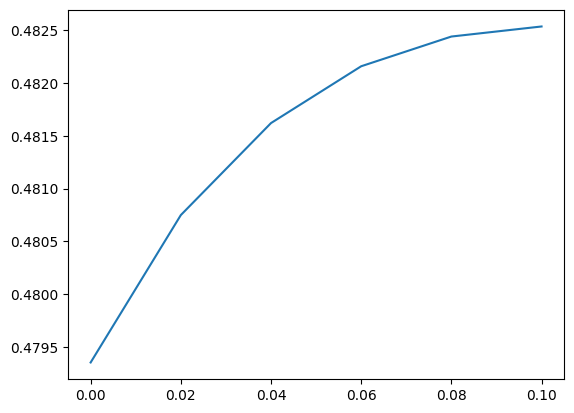

In [18]:
plt.plot(gammas, g2_min[-1,:])

In [ ]:
n_g2_min

np.float64(0.5020514695074314)

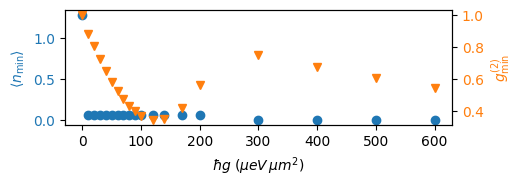

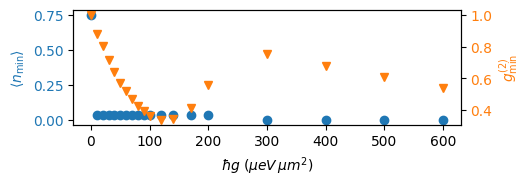

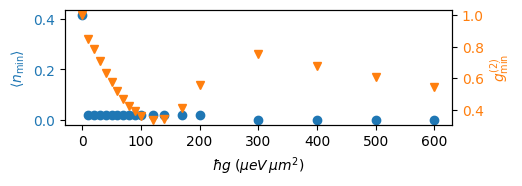

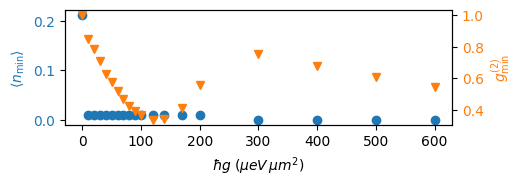

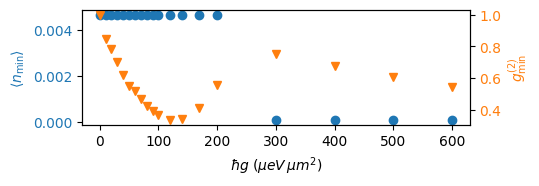

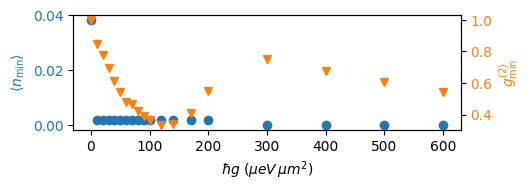

In [11]:
for i, gamma in enumerate(gammas):
    fig, ax1 = plt.subplots(figsize=(5,1.5))

    # left y-axis (blue)
    ax1.plot(hgs[:-1], n_g2_min[:-1,i], "o", color="tab:blue")
    ax1.set_xlabel(r"$\hbar g\; (\mu eV \,\mu m^2)$")
    ax1.set_ylabel(r"$\langle n_\mathrm{min} \rangle$", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    # right y-axis (orange)
    ax2 = ax1.twinx()
    ax2.plot(hgs[:-1], g2_min[:-1, i], "v", color="tab:orange")
    ax2.set_ylabel(r"$g^{(2)}_\text{min}$", color="tab:orange")
    ax2.tick_params(axis="y", labelcolor="tab:orange")

    plt.show()

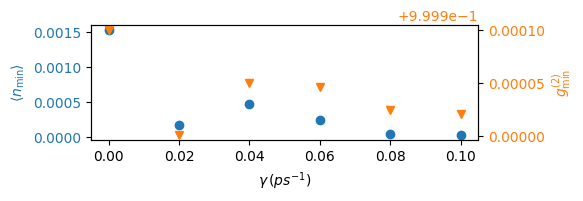

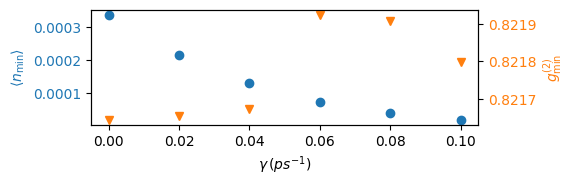

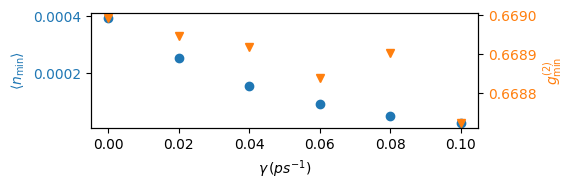

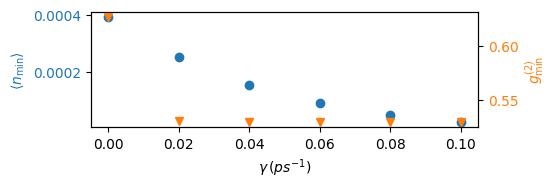

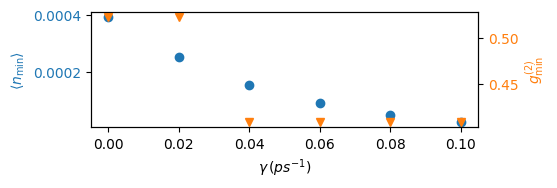

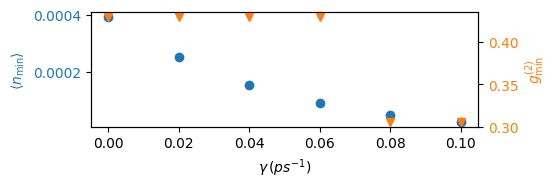

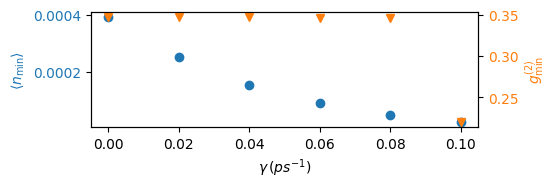

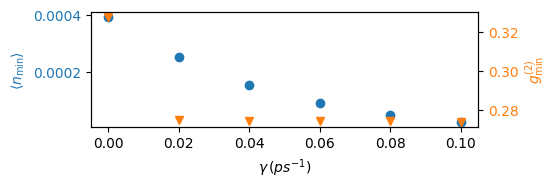

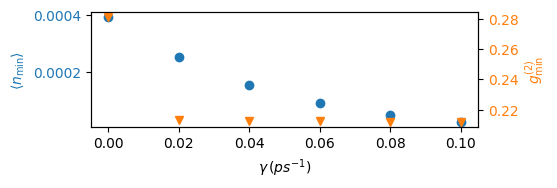

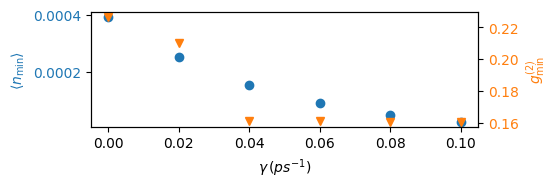

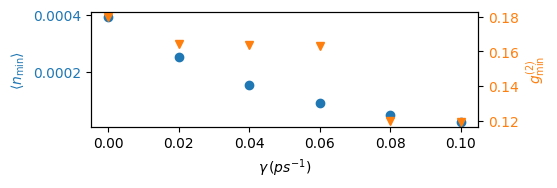

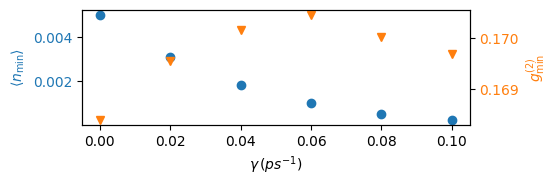

In [ ]:
for i, hg in enumerate(hgs):
    fig, ax1 = plt.subplots(figsize=(5,1.5))

    # left y-axis (blue)
    ax1.plot(gammas, n_g2_min[i], "o", color="tab:blue")
    ax1.set_xlabel(r"$\gamma\, (ps^{-1})$")
    ax1.set_ylabel(r"$\langle n_\mathrm{min} \rangle$", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    # right y-axis (orange)
    ax2 = ax1.twinx()
    ax2.plot(gammas, g2_min[i], "v", color="tab:orange")
    ax2.set_ylabel(r"$g^{(2)}_\text{min}$", color="tab:orange")
    ax2.tick_params(axis="y", labelcolor="tab:orange")

    plt.show()

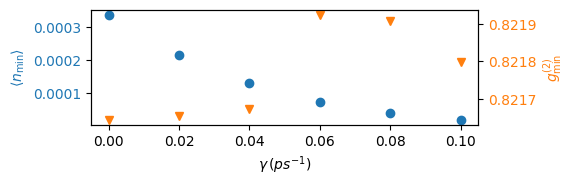

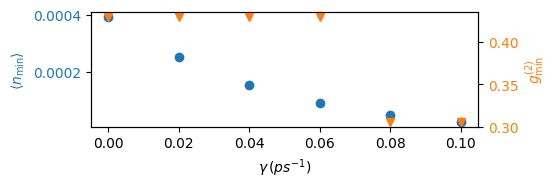

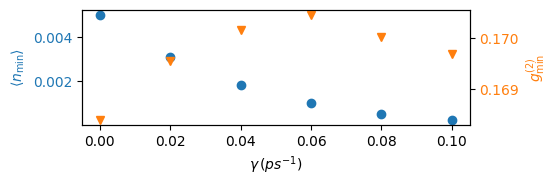

In [ ]:

for i, hg in enumerate(hgs):
    fig, ax1 = plt.subplots(figsize=(5,1.5))

    # left y-axis (blue)
    ax1.plot(gammas, n_g2_min[i], "o", color="tab:blue")
    ax1.set_xlabel(r"$\gamma\, (ps^{-1})$")
    ax1.set_ylabel(r"$\langle n_\mathrm{min} \rangle$", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    # right y-axis (orange)
    ax2 = ax1.twinx()
    ax2.plot(gammas, g2_min[i], "v", color="tab:orange")
    ax2.set_ylabel(r"$g^{(2)}_\text{min}$", color="tab:orange")
    ax2.tick_params(axis="y", labelcolor="tab:orange")

    plt.show()



# Optimization

In [8]:
import os
import pickle
import sys
import matplotlib.pyplot as plt

# Get project root (one level up from notebook folder)
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.insert(0, project_root)

dir_optim = "data/20260224_021010"

with open(os.path.join(dir_optim, 'data.pkl'), 'rb') as fp:
    print(fp)
    d_optim = pickle.load(fp)

<_io.BufferedReader name='data/20260224_021010/data.pkl'>


Text(0.5, 0, 'iter')

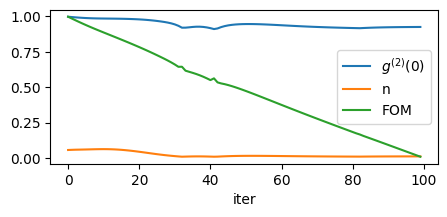

In [15]:
plt.figure(figsize=(5,2))

plt.plot(d_optim['g2_2'])
plt.plot(d_optim['n_2'])
plt.plot(d_optim['FOM'])
plt.legend([r'$g^{(2)}(0)$', r'n', 'FOM'])
plt.xlabel('iter')

In [3]:
type(d_optim)

src.tracker.Tracker